# Goal

We're goign to train Autoencoder model on MNIST dataset. Later on we will occlude images by applying white stripe so the image won't be visible fully. Eventually we're going to see if trained model is able to handle occlusion on the image.

# Data

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
import numpy as np
import copy
from torch.utils.data import TensorDataset, DataLoader

In [2]:
data = np.loadtxt(open('/content/sample_data/mnist_train_small.csv', 'rb'), delimiter = ',')
data = data[:,1:]
data = torch.tensor(data, dtype = torch.float)
data = data / torch.max(data)
data

tensor([[0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 0.],
        ...,
        [0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 0.]])

# Occlusion

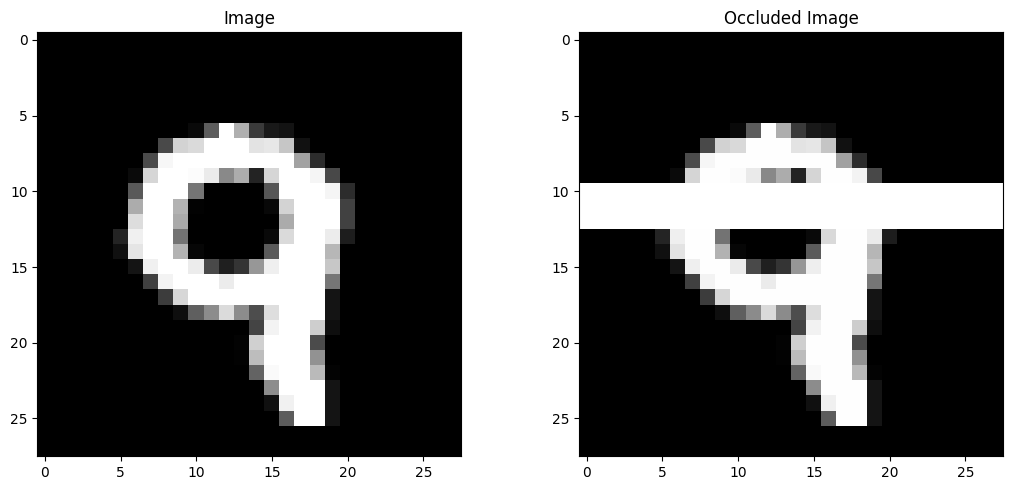

In [3]:
fig, ax = plt.subplots(1,2,figsize = (11,5))

rand_row = np.random.randint(data.shape[0])
img = np.reshape(data[rand_row], (28,28))

occluded_img = copy.deepcopy(img)
occluded_img[10:13,:] = 1

ax[0].imshow(img, cmap = 'grey')
ax[0].set_title('Image')

ax[1].imshow(occluded_img, cmap = 'grey')
ax[1].set_title('Occluded Image')

plt.tight_layout()
plt.show()

# Model

In [4]:
def CreateNet():
  class AENet(nn.Module):
    def __init__(self):
      super().__init__()

      self.inp = nn.Linear(784, 250)
      self.enc = nn.Linear(250, 50)
      self.lat = nn.Linear(50, 250)
      self.dec = nn.Linear(250, 784)

    def forward(self, x):
      x = F.relu(self.inp(x))
      x = F.relu(self.enc(x))
      x = F.relu(self.lat(x))
      x = self.dec(x)
      y = torch.sigmoid(x)
      return y

  net = AENet()
  loss_fn = nn.MSELoss()
  optimizer = torch.optim.Adam(net.parameters(), lr = 1e-3)

  return net, loss_fn, optimizer

In [5]:
x = torch.randn(10, 784)
net, loss_fn, optimizer = CreateNet()
y = net(x)
y

tensor([[0.4883, 0.4929, 0.4806,  ..., 0.5067, 0.5073, 0.5141],
        [0.4879, 0.4880, 0.4874,  ..., 0.5085, 0.5222, 0.5259],
        [0.4927, 0.4908, 0.4800,  ..., 0.5083, 0.5076, 0.5083],
        ...,
        [0.5034, 0.4943, 0.4718,  ..., 0.5007, 0.5050, 0.5144],
        [0.4856, 0.4883, 0.4826,  ..., 0.5082, 0.5079, 0.4989],
        [0.4852, 0.5016, 0.4832,  ..., 0.5091, 0.5101, 0.5053]],
       grad_fn=<SigmoidBackward0>)

# Train

In [6]:
def ModelTrain(epochs, verbose):
  net, loss_fn, optimizer = CreateNet()

  losses = torch.zeros(epochs)

  for epoch in range(epochs):
    random_idxs = np.random.choice(data.shape[0], 32, replace = False)
    x = data[random_idxs, :]

    x_hat = net(x)
    loss = loss_fn(x_hat, x)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    losses[epoch] = loss.item()

    if verbose and epoch%100 == 0:
      print(f'Epoch: {epoch} | Loss: {losses[epoch]:.2f}')

  return losses, net

In [7]:
losses, net = ModelTrain(epochs = 10000, verbose = True)

Epoch: 0 | Loss: 0.23
Epoch: 100 | Loss: 0.06
Epoch: 200 | Loss: 0.04
Epoch: 300 | Loss: 0.03
Epoch: 400 | Loss: 0.03
Epoch: 500 | Loss: 0.02
Epoch: 600 | Loss: 0.02
Epoch: 700 | Loss: 0.02
Epoch: 800 | Loss: 0.02
Epoch: 900 | Loss: 0.02
Epoch: 1000 | Loss: 0.02
Epoch: 1100 | Loss: 0.02
Epoch: 1200 | Loss: 0.02
Epoch: 1300 | Loss: 0.02
Epoch: 1400 | Loss: 0.02
Epoch: 1500 | Loss: 0.01
Epoch: 1600 | Loss: 0.01
Epoch: 1700 | Loss: 0.01
Epoch: 1800 | Loss: 0.01
Epoch: 1900 | Loss: 0.01
Epoch: 2000 | Loss: 0.01
Epoch: 2100 | Loss: 0.01
Epoch: 2200 | Loss: 0.01
Epoch: 2300 | Loss: 0.01
Epoch: 2400 | Loss: 0.01
Epoch: 2500 | Loss: 0.01
Epoch: 2600 | Loss: 0.01
Epoch: 2700 | Loss: 0.01
Epoch: 2800 | Loss: 0.01
Epoch: 2900 | Loss: 0.01
Epoch: 3000 | Loss: 0.01
Epoch: 3100 | Loss: 0.01
Epoch: 3200 | Loss: 0.01
Epoch: 3300 | Loss: 0.01
Epoch: 3400 | Loss: 0.01
Epoch: 3500 | Loss: 0.01
Epoch: 3600 | Loss: 0.01
Epoch: 3700 | Loss: 0.01
Epoch: 3800 | Loss: 0.01
Epoch: 3900 | Loss: 0.01
Epoch: 4000 

# Plot

/tmp/ipython-input-4043484433.py:2: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


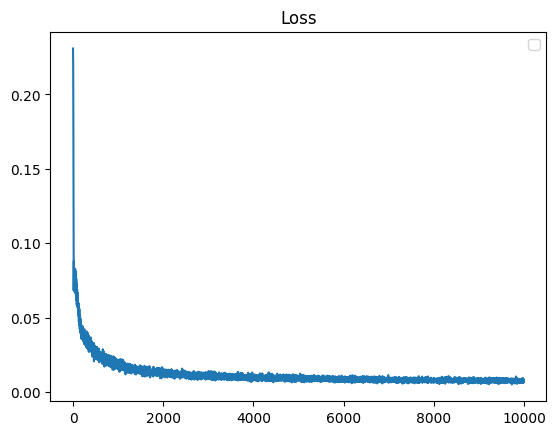

In [8]:
plt.plot(losses)
plt.legend()
plt.title('Loss')
plt.show()

# Add occlusion to some images

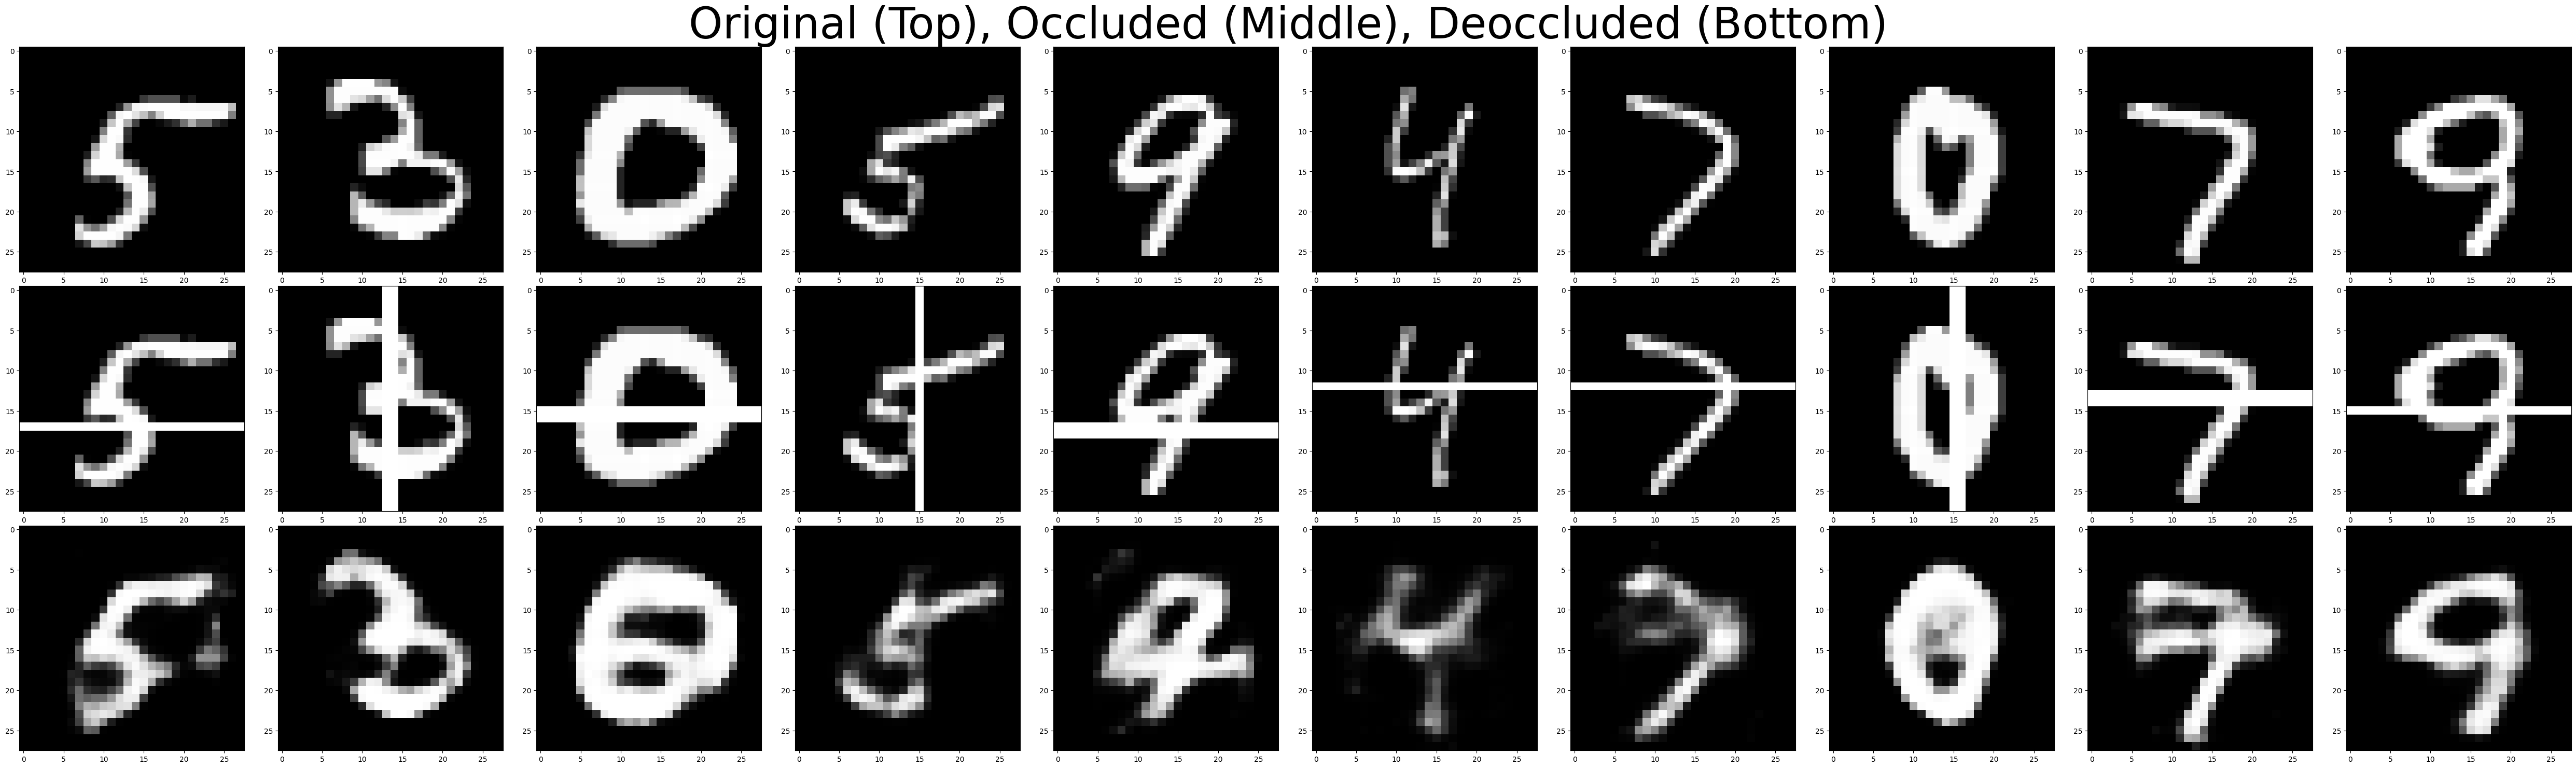

In [9]:
img_cnt = 10

random_idxs = np.random.choice(data.shape[0], img_cnt)


original_imges = []
occluded_imges = []
deoccluded_imges = []

fig, ax = plt.subplots(3, img_cnt, figsize = (img_cnt * 5, 15))

for i in range(img_cnt):
  img = data[random_idxs[i]].view(28,28)
  original_imges.append(img)

# normal
  ax[0][i].imshow(img, cmap = 'grey')

# occluded
  occluded_img = copy.deepcopy(img)
  occluded_imges.append(occluded_img)

  # generate occlusion
  toss = np.random.randn()
  strip_start = np.random.randint(12,18)
  width = np.random.randint(1,3)
  strip_end = strip_start + width

  if toss < .5: # occluded row
    occluded_img[strip_start:strip_end] = 1
  else: # occluded column
    occluded_img[:,strip_start:strip_end] = 1

  ax[1][i].imshow(occluded_img, cmap = 'grey')

# deoccluded
  deoccluded_img = net(occluded_img.view(-1,784)).view(28,28)
  deoccluded_imges.append(deoccluded_img)
  ax[2][i].imshow(deoccluded_img.detach(), cmap = 'grey')

plt.suptitle('Original (Top), Occluded (Middle), Deoccluded (Bottom)', fontsize = 60)
plt.tight_layout()
plt.show()

# Correlation Occluded vs Deoccluded

In [10]:
deoccluded_img.shape, occluded_img.shape

(torch.Size([28, 28]), torch.Size([28, 28]))

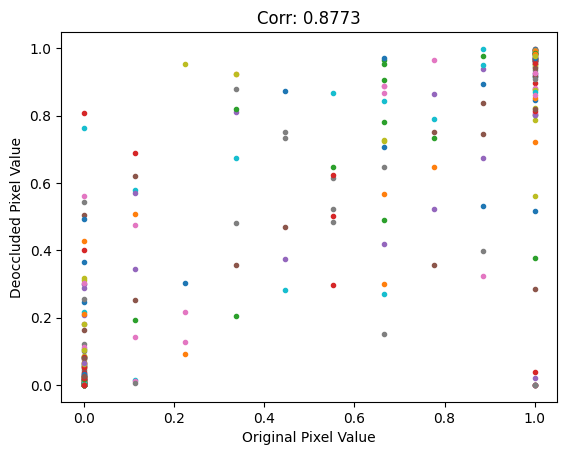

In [11]:
occ = occluded_img.view(-1,784).detach()
deocc = deoccluded_img.view(-1,784).detach()

corr = np.corrcoef(deocc, occ)

plt.plot(occ, deocc, '.')
plt.xlabel('Original Pixel Value')
plt.ylabel('Deoccluded Pixel Value')
plt.title(f'Corr: {corr[0][1]:.4f}')
plt.show()

This is very strong correlation. However, this correlation is hard to explain due to the presence of 0 (dark background of each image). This doesn't fully reflect the shape of our digit. Instead, we should remove all 0's from the images and only after count the correlations.

# Autoendoded Occluded and No-Occluded

Now, let's compare correlation between original image and modeled occluded image (deoccluded) and correlation between original image and modeled original image (no-occluded).

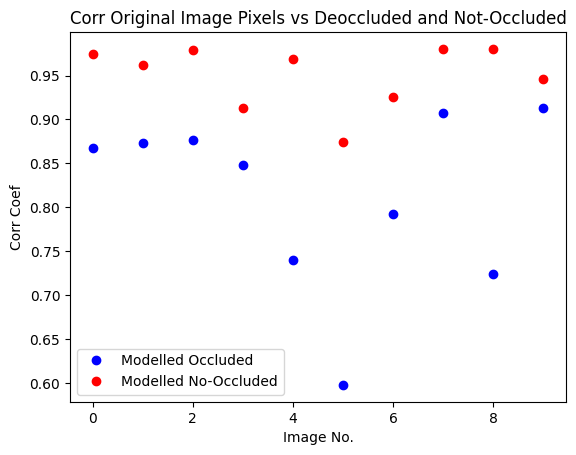

In [12]:

for i in range(10):
  coef = np.corrcoef(original_imges[i].flatten(), deoccluded_imges[i].detach().flatten())
  plt.plot(i, coef[0,1], 'bo')

  no_occluded = net(original_imges[i].flatten())

  coef = np.corrcoef(original_imges[i].flatten(), no_occluded.detach().flatten())
  plt.plot(i, coef[0,1], 'ro')

plt.legend(['Modelled Occluded', 'Modelled No-Occluded'])
plt.title('Corr Original Image Pixels vs Deoccluded and Not-Occluded')
plt.ylabel('Corr Coef')
plt.xlabel('Image No.')
plt.show()

# Correlation Original vs De-Occluded for Each Number

Data

In [13]:
data = np.loadtxt(open('/content/sample_data/mnist_train_small.csv', 'rb'), delimiter = ',')
labels = data[:,0]
data = data[:,1:]
data = torch.tensor(data, dtype = torch.float)
data = data / torch.max(data)
data, labels

(tensor([[0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         ...,
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.]]),
 array([6., 5., 7., ..., 2., 9., 5.]))

Occlusion

In [14]:
occ_data = torch.zeros_like(data)

for i in range(data.shape[0]):
  # generate occlusion
  toss = np.random.randn()
  strip_start = np.random.randint(12,18)
  width = np.random.randint(1,3)
  strip_end = strip_start + width

  occ_data[i] = data[i]
  if toss < .5: # occluded row
    occ_data[i].view(28,28)[strip_start:strip_end] = 1
  else: # occluded column
    occ_data[i].view(28,28)[:,strip_start:strip_end] = 1
  occ_data[i] = occ_data[i].flatten()

Preds

In [15]:
preds = net(occ_data)

Corr

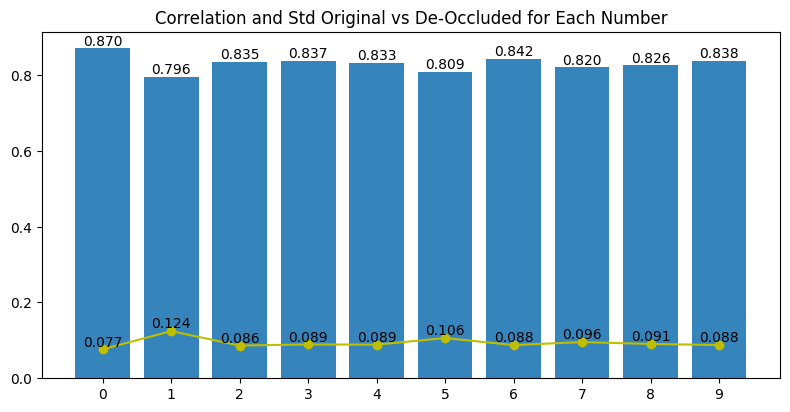

In [16]:
import collections
import numpy as np
import matplotlib.pyplot as plt

corrs = collections.defaultdict(list)

for x, p, lbl in zip(data, preds, labels):
    c = np.corrcoef(x.detach().numpy(), p.detach().numpy())[0, 1]
    corrs[int(lbl)] += [c]

keys = sorted(corrs.keys())
corr_vals = [np.mean(corrs[k]) for k in keys]
std_vals = [np.std(corrs[k]) for k in keys]

plt.figure(figsize=(8,4))
plt.plot(keys, std_vals, 'y-o')
plt.bar(keys, corr_vals, alpha = .9)
plt.xticks(keys)

for x, y in zip(keys, corr_vals):
    plt.text(x, y, f"{y:.3f}", ha="center", va="bottom")

for x, y in zip(keys, std_vals):
    plt.text(x, y, f"{y:.3f}", ha="center", va="bottom")

plt.tight_layout()
plt.title('Correlation and Std Original vs De-Occluded for Each Number')
plt.show()


# Binarized Overlap Pixels Count

In [17]:
data_bin = (data > .5)
preds_bin = (preds > .5)

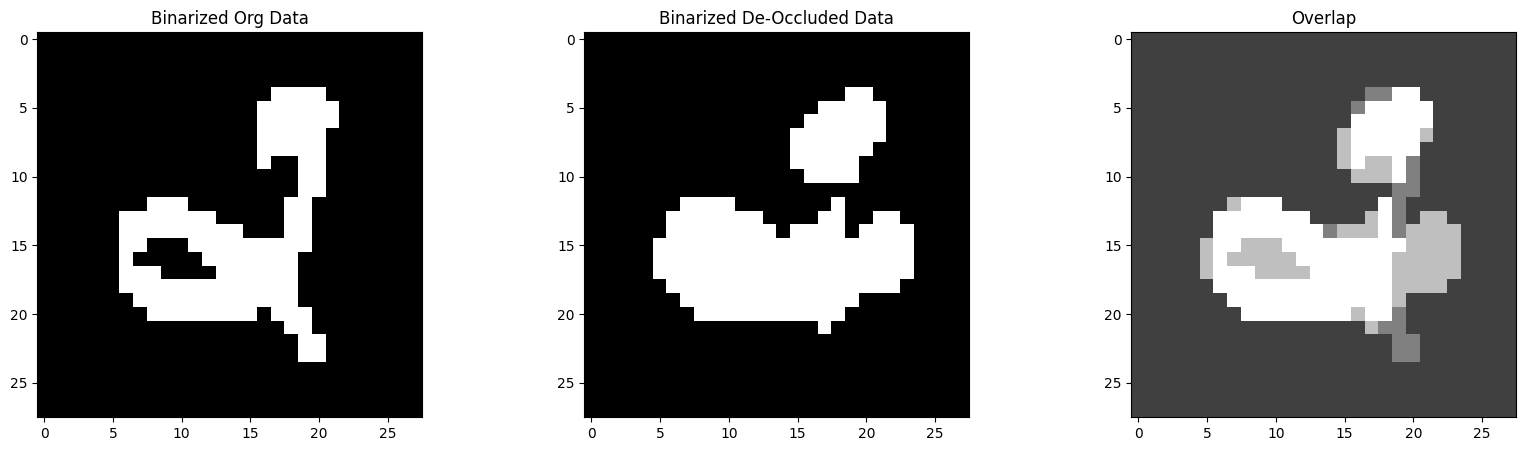

In [18]:
fig, ax = plt.subplots(1,3,figsize=(20,5))

rand_row = np.random.randint(data.shape[0])

ax[0].imshow(data_bin[rand_row].view(28,28), cmap='grey')
ax[0].set_title('Binarized Org Data')
ax[1].imshow(preds_bin[rand_row].view(28,28), cmap = 'grey')
ax[1].set_title('Binarized De-Occluded Data')

ax[2].imshow(data_bin[rand_row].view(28,28), cmap='grey', alpha=.5, label='Original')
ax[2].imshow(preds_bin[rand_row].view(28,28), cmap='grey', alpha=.5, label = 'De-Occluded')
ax[2].set_title('Overlap')

plt.show()

In [19]:
import collections
import numpy as np
import matplotlib.pyplot as plt

overlaps = collections.defaultdict(list)

# overlap_bin ma shape [N, 784] lub [N, 28*28]
for x, lbl in zip(overlap_bin, labels):
    s = np.sum(x.detach().numpy())   # ile trafień w tej próbce
    overlaps[int(lbl)].append(s)

keys = sorted(overlaps.keys())
overlaps_vals = [np.mean(overlaps[k]) for k in keys]

plt.figure(figsize=(8,4))
plt.bar(keys, overlaps_vals, alpha=0.9)
plt.xticks(keys)

for x, y in zip(keys, overlaps_vals):
    plt.text(x, y, f"{y:.3f}", ha='center', va='bottom')

plt.tight_layout()
plt.title('Mean Overlap Pixels (Original ∧ De-Occluded) per Digit')
plt.show()


NameError: name 'overlap_bin' is not defined

Mean MSE Losses Original vs De-Occluded per Digit

In [ ]:
import collections
import numpy as np
import matplotlib.pyplot as plt

mses = collections.defaultdict(list)
loss_fn = nn.MSELoss()

# overlap_bin ma shape [N, 784] lub [N, 28*28]
for x, y, lbl in zip(data, preds, labels):
    s = loss_fn(x.detach(), y.detach()).item()
    mses[int(lbl)].append(s)

keys = sorted(mses.keys())
mses_vals = [np.mean(mses[k]) for k in keys]

plt.figure(figsize=(8,4))
plt.bar(keys, mses_vals, alpha=0.9)
plt.xticks(keys)

for x, y in zip(keys, mses_vals):
    plt.text(x, y, f"{y:.3f}", ha='center', va='bottom')

plt.tight_layout()
plt.title('Mean MSE Loss Pixels (Original ∧ De-Occluded) per Digit')
plt.show()